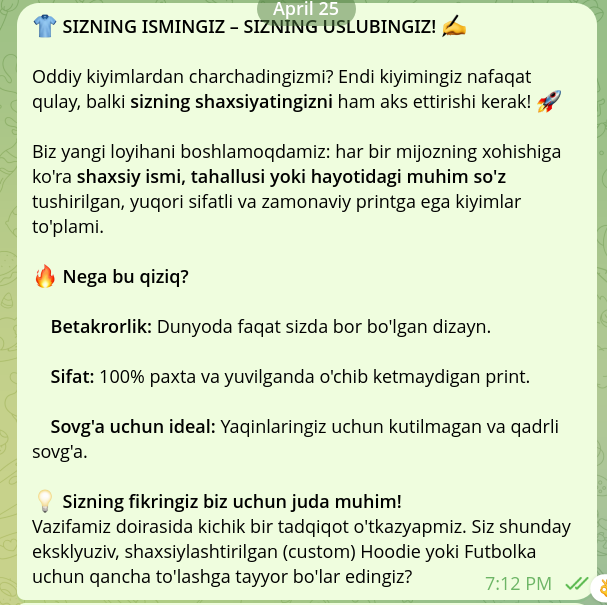

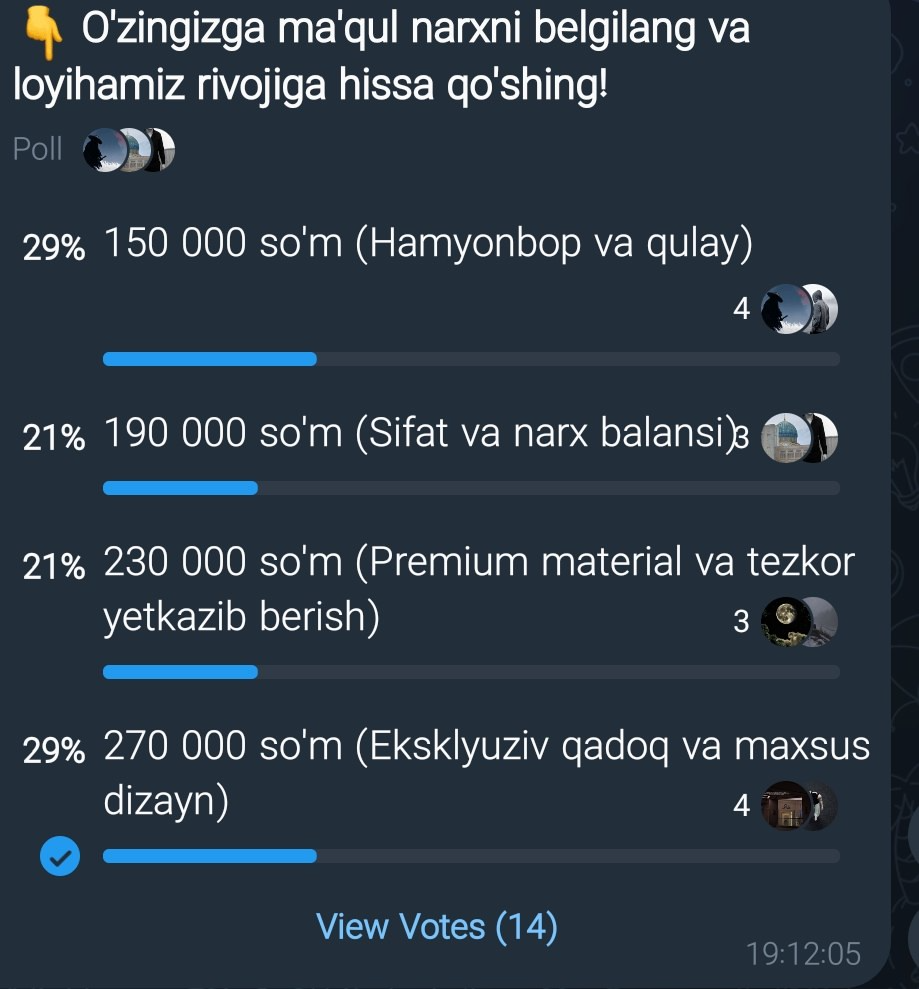

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [189]:
data = {150_000: 4, 190_000: 3, 230_000: 3, 270_000: 4}
df = pd.DataFrame(list(data.items()), columns=['Price(X)', 'Votes'])
df = df.sort_values(by='Price(X)', ascending=False)
df['Count(Y)'] = df['Votes'].cumsum()
df.loc['total'] = df.sum()
df.head()

,Price(X),Votes,Count(Y)
3,270000,4,4
2,230000,3,7
1,190000,3,10
0,150000,4,14
total,840000,14,35


In [190]:
df['MX'] = df['Count(Y)'] * df['Price(X)']
df.loc['total', 'MX'] = df['MX'].sum() - df.loc['total', 'MX']
df.head()

,Price(X),Votes,Count(Y),MX
3,270000,4,4,1080000
2,230000,3,7,1610000
1,190000,3,10,1900000
0,150000,4,14,2100000
total,840000,14,35,6690000


In [191]:
df['X2'] = df['Price(X)'] ** 2
df.loc['total', 'X2'] = df['X2'].sum() - df.loc['total', 'X2']
df['Y2'] = df['Count(Y)'] ** 2
df.loc['total', 'Y2'] = df['Y2'].sum() - df.loc['total', 'Y2']
df.head()

,Price(X),Votes,Count(Y),MX,X2,Y2
3,270000,4,4,1080000,72900000000,16
2,230000,3,7,1610000,52900000000,49
1,190000,3,10,1900000,36100000000,100
0,150000,4,14,2100000,22500000000,196
total,840000,14,35,6690000,184400000000,361


In [209]:
n = df.shape[0] - 1
mx = df.loc['total', 'MX']
x = df.loc['total', 'Price(X)']
y = df.loc['total', 'Count(Y)']
y2 = df.loc['total', 'Y2'] 
x2 = df.loc['total', 'X2']
b1 = (n*mx - x * y) / (n*x2 - x ** 2)
b0 = (y - b1 * x) / n
print(f"b0: {b0}, b1: {b1}")

b0: 26.075, b1: -8.25e-05


In [204]:
df.head()

,Price(X),Votes,Count(Y),MX,X2,Y2
3,270000,4,4,1080000,72900000000,16
2,230000,3,7,1610000,52900000000,49
1,190000,3,10,1900000,36100000000,100
0,150000,4,14,2100000,22500000000,196
total,840000,14,35,6690000,184400000000,361


In [211]:
ryx = (n*mx - x * y) / np.sqrt((n*x2 - x ** 2) * (n*y2 - y ** 2))
R2 = ryx ** 2
R2

np.float64(0.9945205479452055)

In [212]:
# R = b1*x^2 + b0*x
# R' = 2*b1*x + b0 = 0
# x = b0 / (2*b1)
x = b0 / (-2*b1)
x

np.float64(158030.30303030304)

In [213]:
R_func = lambda x: b1*x**2 + b0*x
R_func(x)

np.float64(2060320.0757575757)

In [214]:
df.drop('total', inplace=True)

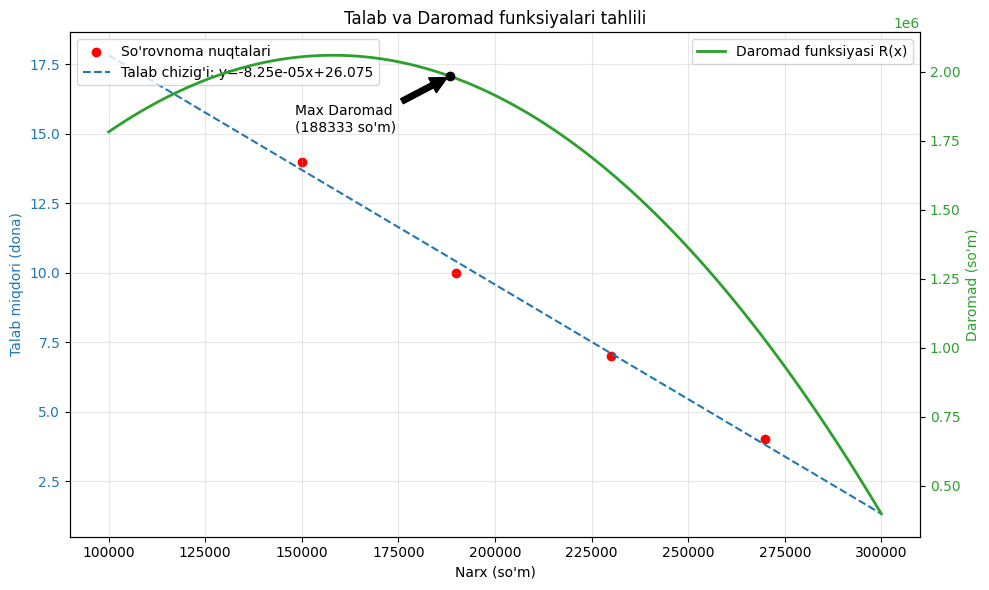

In [215]:
x = 188333
max_revenue = R_func(x)

x_range = np.linspace(100000, 300000, 100)
y_demand = b1 * x_range + b0
y_revenue = b1 * (x_range**2) + b0 * x_range

fig, ax1 = plt.subplots(figsize=(10, 6))

color = 'tab:blue'
ax1.set_xlabel("Narx (so'm)")
ax1.set_ylabel('Talab miqdori (dona)', color=color)
ax1.scatter(df['Price(X)'], df['Count(Y)'], color='red', label="So'rovnoma nuqtalari")
ax1.plot(x_range, y_demand, color=color, linestyle='--', label=f"Talab chizig'i: y={b1}x+{b0}")
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
color = 'tab:green'
ax2.set_ylabel("Daromad (so'm)", color=color)
ax2.plot(x_range, y_revenue, color=color, linewidth=2, label='Daromad funksiyasi R(x)')
ax2.tick_params(axis='y', labelcolor=color)

ax2.plot(x, max_revenue, 'ko') 
ax2.annotate(f"Max Daromad\n({x:.0f} so'm)", 
             xy=(x, max_revenue), 
             xytext=(x-40000, max_revenue-200000),
             arrowprops=dict(facecolor='black', shrink=0.05))

plt.title('Talab va Daromad funksiyalari tahlili')
fig.tight_layout()
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')

plt.show()

## Conclution

Based on the updated data and the demand function y=−8.25e−05x+26.075, the following analytical conclusions have been drawn:

    Validation of Demand Theory: The empirical data confirms that as the price decreases, the cumulative demand increases significantly. Specifically, lowering the price from 270,000 to 150,000 soums resulted in demand growing from 4 to 14 units, validating the fundamental Law of Demand.

    Statistical Reliability: The linear regression model effectively captures the consumer behavior trends. With a high coefficient of determination (R2), the model demonstrates strong predictive power regarding price-demand elasticity.

    Revenue Optimization: Analytical modeling of the revenue function reveals that the maximum gross revenue for this project is approximately 2,060,000 soums. To maximize financial returns, the optimal market price should be established at approximately 158,000 soums.

    Optimal Production Scale: At the peak of the revenue parabola, the optimal production volume is identified as 13 units. The analysis suggests that this balance point provides the most efficient trade-off between profit margins and sales volume.

    Market Positioning: To maintain sustainable growth, it is recommended to position the product within the 150,000 to 170,000 soum price range, where consumer sensitivity to price changes is most balanced with revenue goals.